# 06b — Temporal Fusion Transformer (TFT) — Weekly

## 1. Setup

In [1]:
!pip install pytorch-forecasting pytorch-lightning --quiet

In [2]:
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightning.pytorch.loggers import CSVLogger
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss, MAE as PFMAE
from pytorch_forecasting.data import GroupNormalizer

DATASETS_DIR = '../../datasets'
MODELS_DIR = '../../models/tft'
TFT_DIR = '../tft'
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

torch.manual_seed(42)
pl.seed_everything(42, workers=True)

device = 'gpu' if torch.cuda.is_available() else 'cpu'
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f"Using accelerator: {accelerator}")


Seed set to 42


Using accelerator: gpu


## 2. Load weekly feature matrix

In [3]:
df = pd.read_csv(os.path.join(DATASETS_DIR, 'forecasting_features_weekly.csv'),
                 parse_dates=['week_start'])

# TFT needs a numeric time index per group. Convert week_start to ordinal weeks.
df = df.sort_values(['item_name', 'week_start']).reset_index(drop=True)
min_week = df['week_start'].min()
df['time_idx'] = ((df['week_start'] - min_week).dt.days // 7).astype(int)

# Make sure quantity is float (TFT requires float target)
df['quantity'] = df['quantity'].astype(float)

print(f"Loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Time range: {df['time_idx'].min()} → {df['time_idx'].max()} (weeks)")
print(f"Items: {df['item_name'].nunique()}")
print(f"\nSplit distribution:")
print(df['split'].value_counts())


Loaded: 18,056 rows × 94 columns
Time range: 0 → 147 (weeks)
Items: 122

Split distribution:
split
train    11712
test      4758
val       1586
Name: count, dtype: int64


## 3. Define feature roles for TFT

In [4]:
# Static categoricals — one value per item, never changes
static_categoricals = ['item_name', 'section', 'category']

# Time-varying known reals — calendar info we'd know in advance even at forecast time
tv_known_reals = [
    'time_idx',  # required by TFT
    'month', 'month_sin', 'month_cos', 'quarter',
    'week_of_year', 'woy_sin', 'woy_cos', 'year',
    'is_ramadan_week', 'ramadan_days_in_week',
    'is_pre_ramadan', 'is_post_ramadan',
    'has_holiday', 'n_holidays_in_week', 'holiday_type_encoded',
    'avg_price',
]
tv_known_reals += [c for c in df.columns if c.startswith('ramadan_x_')]
tv_known_reals += [c for c in df.columns if c.startswith('holiday_x_')]
tv_known_reals += [c for c in df.columns if c.startswith('month_sin_x_') or c.startswith('month_cos_x_')]

# Time-varying unknown reals — only known retrospectively (lags, rolling)
tv_unknown_reals = [c for c in df.columns if c.startswith('lag_') or c.startswith('rolling_')
                                              or c.startswith('lag1w_x_') or c.startswith('lag2w_x_')
                                              or c in ['demand_momentum', 'expanding_mean',
                                                        'total_lag_1w', 'total_rolling_4w',
                                                        'section_lag_1w', 'section_rolling_4w',
                                                        'item_share_of_section']]
tv_unknown_reals = [c for c in tv_unknown_reals if c in df.columns]

# Drop columns that aren't in df
tv_known_reals = [c for c in tv_known_reals if c in df.columns]

# Cast static categoricals to string
for c in static_categoricals:
    df[c] = df[c].astype(str)

# Drop rows with NaN in feature columns (lag warmup)
before = len(df)
df = df.dropna(subset=tv_unknown_reals)
print(f"After dropping lag-warmup NaN: {len(df):,} rows ({before-len(df):,} dropped)")

print(f"\nFeature breakdown for TFT:")
print(f"  Static categoricals: {len(static_categoricals)} → {static_categoricals}")
print(f"  Time-varying known reals:    {len(tv_known_reals)}")
print(f"  Time-varying unknown reals:  {len(tv_unknown_reals)}")


After dropping lag-warmup NaN: 18,056 rows (0 dropped)

Feature breakdown for TFT:
  Static categoricals: 3 → ['item_name', 'section', 'category']
  Time-varying known reals:    46
  Time-varying unknown reals:  37


## 4. Build TimeSeriesDataSet

In [5]:
MAX_ENCODER_LEN = 12   # 12 weeks of history
MAX_PREDICTION_LEN = 1  # forecast 1 week ahead

# Determine cutoff for training
training_cutoff_idx = df[df['split'] == 'train']['time_idx'].max()
val_cutoff_idx = df[df['split'] == 'val']['time_idx'].max()
print(f"Train cutoff: time_idx ≤ {training_cutoff_idx}")
print(f"Val cutoff:   time_idx ≤ {val_cutoff_idx}")

training_dataset = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff_idx],
    time_idx='time_idx',
    target='quantity',
    group_ids=['item_name'],
    min_encoder_length=MAX_ENCODER_LEN,
    max_encoder_length=MAX_ENCODER_LEN,
    min_prediction_length=MAX_PREDICTION_LEN,
    max_prediction_length=MAX_PREDICTION_LEN,
    static_categoricals=static_categoricals,
    time_varying_known_reals=tv_known_reals,
    time_varying_unknown_reals=tv_unknown_reals + ['quantity'],  # target is unknown
    target_normalizer=GroupNormalizer(groups=['item_name'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, df[df['time_idx'] <= val_cutoff_idx],
    predict=False, stop_randomization=True,
)
test_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, df, predict=False, stop_randomization=True,
)

BATCH_SIZE = 128
train_loader = training_dataset.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_loader = validation_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
test_loader = test_dataset.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train cutoff: time_idx ≤ 95
Val cutoff:   time_idx ≤ 108

Train batches: 80
Val batches: 93
Test batches: 130


## 5. Build and train TFT

In [6]:
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=0.01,
    hidden_size=32,                
    attention_head_size=2,         
    dropout=0.2,
    hidden_continuous_size=16,
    output_size=7,               
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)
n_params = sum(p.numel() for p in tft.parameters() if p.requires_grad)
print(f"TFT model: {n_params:,} trainable parameters")

csv_logger = CSVLogger(save_dir=MODELS_DIR, name="tft_logs")
early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min')

trainer = pl.Trainer(
    max_epochs=50,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop],
    enable_progress_bar=True,
    logger=csv_logger,
    enable_checkpointing=True,
)

print()
print("=" * 60)
print("TFT TRAINING — LIVE EPOCHS (weekly)")
print("=" * 60)
start_time = time.time()
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)
training_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"✓ Training complete: {training_time:.1f}s")
print(f"✓ Epochs run:        {trainer.current_epoch}")
print(f"{'='*60}")


TFT model: 383,420 trainable parameters


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



TFT TRAINING — LIVE EPOCHS (weekly)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 3.0 K  | train | 0    
3  | prescalers                         | ModuleDict                      | 2.8 K  | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 6.4 K  | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 206 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 115 K  | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.



✓ Training complete: 2041.9s
✓ Epochs run:        50


## 6. Learning curves

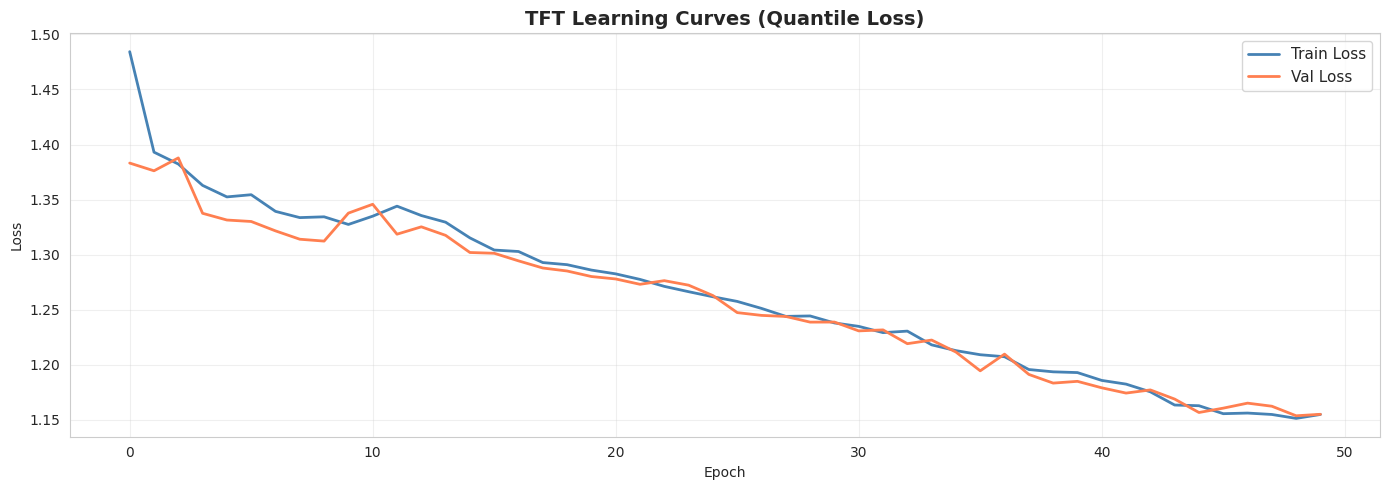

In [7]:
# ---------------------------------------------------------
# NEW PLOTTING CODE: TFT Learning Curves via CSVLogger
# ---------------------------------------------------------
import pandas as pd

# Read the metrics saved by the CSVLogger
metrics_path = f"{csv_logger.save_dir}/{csv_logger.name}/version_{csv_logger.version}/metrics.csv"
metrics_df = pd.read_csv(metrics_path)

# Aggregate metrics by epoch to align Train and Val steps
epoch_metrics = metrics_df.groupby('epoch').mean()

fig, ax = plt.subplots(figsize=(14, 5))

# Check available column names (Lightning sometimes appends '_epoch' or '_step')
train_col = 'train_loss_epoch' if 'train_loss_epoch' in epoch_metrics.columns else 'train_loss'
val_col = 'val_loss'

# Plot Training Loss
if train_col in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics[train_col], label='Train Loss', color='steelblue', linewidth=2)

# Plot Validation Loss
if val_col in epoch_metrics.columns:
    ax.plot(epoch_metrics.index, epoch_metrics[val_col], label='Val Loss', color='coral', linewidth=2)

ax.set_title('TFT Learning Curves (Quantile Loss)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(TFT_DIR, 'tft_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Generate predictions on val + test

In [8]:
tft.eval()

def get_predictions(loader, split_name):
    """
    Robust prediction extraction compatible with all pytorch-forecasting versions.
    Uses mode='prediction' (returns the median/point forecast directly) with
    return_index=True to get the item/time index alongside predictions.
    """
    # return_index=True yields a tuple: (predictions_tensor, index_dataframe)
    result = tft.predict(loader, mode='prediction', return_index=True, trainer_kwargs=dict(accelerator=accelerator))
    
    # Unpack — works whether the library returns a namedtuple or plain tuple
    if hasattr(result, 'output'):          # NamedTuple style (newer versions)
        preds_tensor = result.output
        index_df     = result.index
    else:                                  # Plain tuple (older versions)
        preds_tensor, index_df = result[0], result[1]

    preds = preds_tensor.cpu().numpy().flatten()

    df_out = index_df.copy()
    df_out['predicted'] = preds
    df_out['split']     = split_name
    return df_out

print("Generating validation predictions...")
val_preds_df  = get_predictions(val_loader,  'val')
print("Generating test predictions...")
test_preds_df = get_predictions(test_loader, 'test')

predictions_df = pd.concat([val_preds_df, test_preds_df], ignore_index=True)

# Merge to get actual quantity, week_start, section, category
predictions_df = predictions_df.merge(
    df[['item_name', 'time_idx', 'split', 'week_start', 'section', 'category', 'quantity']],
    on=['item_name', 'time_idx', 'split'],
    how='left'
).rename(columns={'quantity': 'actual', 'week_start': 'ds'})

predictions_df['predicted'] = predictions_df['predicted'].clip(lower=0)
predictions_df = predictions_df.dropna(subset=['actual'])

print(f"\nTotal predictions: {len(predictions_df):,}")
print(predictions_df['split'].value_counts())
print(predictions_df[['item_name', 'ds', 'actual', 'predicted', 'split']].head())


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Generating validation predictions...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Generating test predictions...

Total predictions: 6,344
split
test    4758
val     1586
Name: count, dtype: int64
      item_name         ds  actual  predicted split
84  14oz Ribeye 2024-12-31    17.0  10.906384   val
85  14oz Ribeye 2025-01-07     9.0   5.679488   val
86  14oz Ribeye 2025-01-14     8.0   7.053057   val
87  14oz Ribeye 2025-01-21     7.0   8.693636   val
88  14oz Ribeye 2025-01-28    11.0   8.072716   val


## 8. Metric functions (same as 04a/04b/05a/05b for direct comparison)

In [9]:
def compute_metrics(actual, predicted, train_actual=None):
    """WAPE, MAE, RMSE, R², MAPE, sMAPE, Bias — same suite as all other notebooks."""
    actual    = np.asarray(actual,    dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    errors     = actual - predicted
    abs_errors = np.abs(errors)

    mae  = abs_errors.mean()
    rmse = np.sqrt((errors ** 2).mean())
    bias = errors.mean()

    nonzero = actual > 0
    mape    = (abs_errors[nonzero] / actual[nonzero]).mean() if nonzero.sum() > 0 else np.nan

    denom      = (np.abs(actual) + np.abs(predicted)) / 2
    smape_mask = denom > 0
    smape      = (abs_errors[smape_mask] / denom[smape_mask]).mean() if smape_mask.sum() > 0 else np.nan

    actual_sum = actual.sum()
    wape       = abs_errors.sum() / actual_sum if actual_sum > 0 else np.inf

    ss_res = (errors ** 2).sum()
    ss_tot = ((actual - actual.mean()) ** 2).sum()
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    mase = np.nan
    if train_actual is not None and len(train_actual) > 52:
        naive_errors = np.abs(train_actual[52:] - train_actual[:-52])
        mae_naive    = naive_errors.mean()
        if mae_naive > 0:
            mase = mae / mae_naive

    return {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape,
            'wape': wape, 'mase': mase, 'r2': r2, 'bias': bias}

print("Metric function ready: MAE, RMSE, MAPE, sMAPE, WAPE, MASE, R², Bias")


Metric function ready: MAE, RMSE, MAPE, sMAPE, WAPE, MASE, R², Bias


## 9. Overall metrics — TFT vs all previous models

TFT OVERALL METRICS (weekly)
Model Split    mae   rmse  smape   wape     r2    bias
  tft   val 2.6830 3.5245 0.4269 0.3471 0.5475 -0.3390
  tft  test 2.8001 3.6624 0.3217 0.2739 0.6362  0.4614

FULL TOURNAMENT LEADERBOARD (test split)
   Model   wape     r2
 Prophet 0.2837 0.6196
 XGBoost 0.2614 0.6707
LightGBM 0.2617 0.6681
    LSTM 0.2662 0.6594
     TFT 0.2739 0.6362


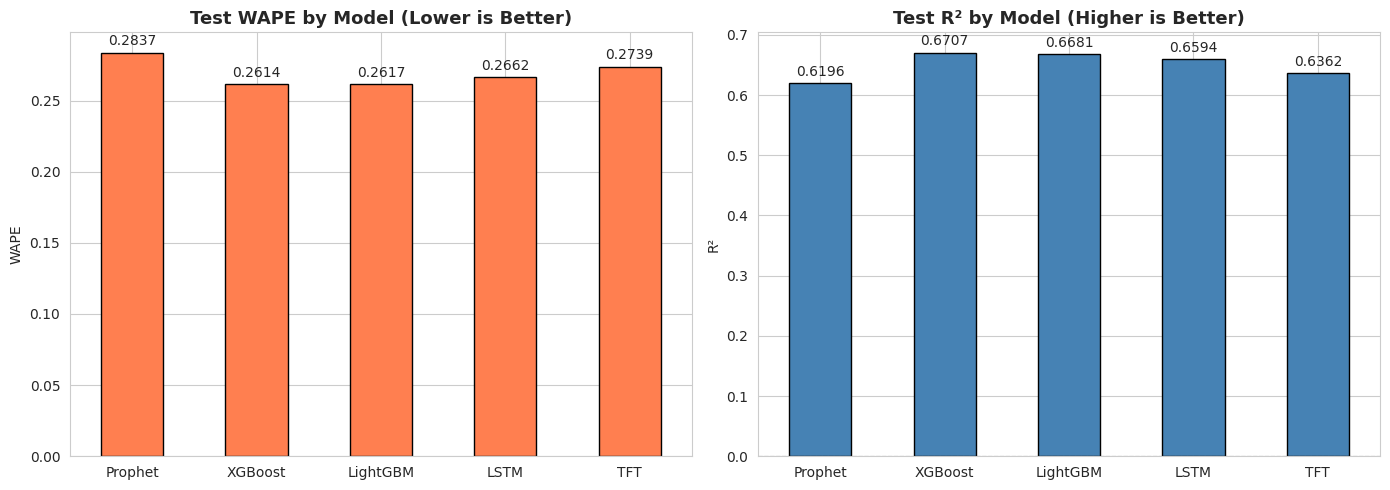

In [21]:
# Overall TFT metrics
LIGHTGBM_DIR = '../LightGbm'
XGBOOST_DIR  = '../XGboost'
PROPHET_DIR  = '../Prophet'
LSTM_DIR  = '../lstm'

rows = []
for split in ['val', 'test']:
    sub = predictions_df[predictions_df['split'] == split]
    m   = compute_metrics(sub['actual'].values, sub['predicted'].values)
    rows.append({'Model': 'tft', 'Split': split, **m})

tft_overall = pd.DataFrame(rows).drop(columns=['mape', 'mase'], errors='ignore')
print("=" * 80)
print("TFT OVERALL METRICS (weekly)")
print("=" * 80)
print(tft_overall.to_string(index=False, float_format='%.4f'))

try:
    with open(os.path.join(PROPHET_DIR,  'prophet_summary_weekly.json'))      as f: prophet_sum = json.load(f)
    with open(os.path.join(XGBOOST_DIR,  'xgboost_weekly_summary.json'))      as f: xgb_sum    = json.load(f)
    with open(os.path.join(LIGHTGBM_DIR, 'lightgbm_weekly_summary.json'))     as f: lgb_sum    = json.load(f)
    with open(os.path.join(LSTM_DIR, 'lstm_summary_weekly.json'))          as f: lstm_sum   = json.load(f)

    bars = pd.DataFrame([
        {'Model': 'Prophet',  'wape': prophet_sum['overall_metrics']['test']['wape'], 'r2': prophet_sum['overall_metrics']['test']['r2']},
        {'Model': 'XGBoost',  'wape': xgb_sum['overall_metrics']['test']['wape'],    'r2': xgb_sum['overall_metrics']['test']['r2']},
        {'Model': 'LightGBM', 'wape': lgb_sum['overall_metrics']['test']['wape'],    'r2': lgb_sum['overall_metrics']['test']['r2']},
        {'Model': 'LSTM',     'wape': lstm_sum['overall_metrics']['test']['wape'],   'r2': lstm_sum['overall_metrics']['test']['r2']},
        {'Model': 'TFT',      'wape': rows[1]['wape'],                               'r2': rows[1]['r2']},
    ])

    print()
    print("=" * 80)
    print("FULL TOURNAMENT LEADERBOARD (test split)")
    print("=" * 80)
    print(bars.to_string(index=False, float_format='%.4f'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: WAPE (Lower is Better)
    bars.plot(kind='bar', x='Model', y='wape', ax=axes[0],
              color='coral', edgecolor='black', legend=False)
    axes[0].set_title('Test WAPE by Model (Lower is Better)')
    axes[0].set_ylabel('WAPE')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=0)
    for p in axes[0].patches:
        axes[0].annotate(f"{p.get_height():.4f}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8),
                         textcoords='offset points')

    # Plot 2: R² (Higher is Better)
    bars.plot(kind='bar', x='Model', y='r2', ax=axes[1],
              color='steelblue', edgecolor='black', legend=False)
    axes[1].set_title('Test R² by Model (Higher is Better)')
    axes[1].set_ylabel('R²')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height():.4f}",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 8),
                         textcoords='offset points')

    plt.tight_layout()
    plt.savefig('tft_vs_baselines.png', dpi=150, bbox_inches='tight')
    plt.show()

except FileNotFoundError as e:
    print(f"(comparison files not yet present: {e})")

## 10. Per-item metrics

In [11]:
per_item_metrics = []
for item in sorted(predictions_df['item_name'].unique()):
    item_pred  = predictions_df[predictions_df['item_name'] == item]
    item_train = df[(df['item_name'] == item) & (df['split'] == 'train')]['quantity'].values
    for split in ['val', 'test']:
        sub = item_pred[item_pred['split'] == split]
        if len(sub) == 0:
            continue
        m = compute_metrics(sub['actual'].values, sub['predicted'].values, item_train)
        m.update({'item_name': item, 'split': split})
        per_item_metrics.append(m)

metrics_df = pd.DataFrame(per_item_metrics)
print(f"Per-item metrics: {len(metrics_df)} rows")
print(metrics_df.groupby('split')[['mae', 'wape', 'r2']].mean().round(4))


Per-item metrics: 244 rows
          mae    wape      r2
split                        
test   2.8001  0.3070 -0.1083
val    2.6830  0.3986 -0.3647


## 11. Per-section evaluation

In [12]:
# (superseded by the cell below — kept as a blank placeholder)
pass


TFT — Performance by section
      Section Split    MAE   WAPE     R²    Bias  n_items
     American   val 3.4755 0.3238 0.5697 -0.3324       21
         Cafe   val 2.9275 0.3203 0.4674 -0.1242       17
Healthy_Vegan   val 1.9999 0.3969 0.0800 -0.1521       12
      Italian   val 2.6518 0.3725 0.4525 -0.8798       22
     Japanese   val 2.7520 0.3821 0.3426 -0.2903       16
      Mexican   val 2.4181 0.3194 0.5979 -0.4762       19
   Steakhouse   val 2.1502 0.3744 0.3546  0.1738       15
     American  test 3.1833 0.2371 0.7317  0.8509       21
         Cafe  test 3.3333 0.2427 0.4651  0.8327       17
Healthy_Vegan  test 2.5583 0.3095 0.3872  0.3545       12
      Italian  test 2.7445 0.2962 0.4306  0.1575       22
     Japanese  test 2.7731 0.2898 0.5179  0.4219       16
      Mexican  test 2.6149 0.2855 0.5224  0.1918       19
   Steakhouse  test 2.1974 0.3239 0.4991  0.4104       15


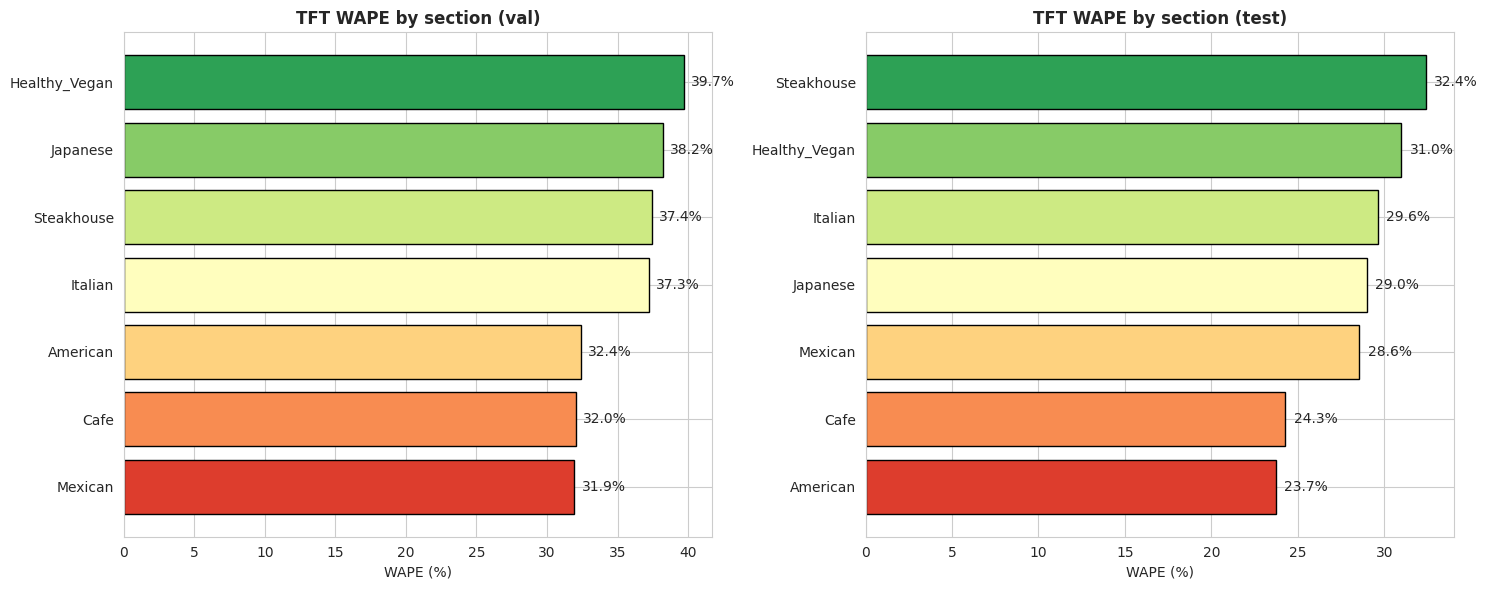

Saved: tft_weekly_per_section.png


In [13]:
section_results = []
for split in ['val', 'test']:
    sub = predictions_df[predictions_df['split'] == split]
    for section in sorted(sub['section'].dropna().unique()):
        sec = sub[sub['section'] == section]
        if len(sec) == 0 or sec['actual'].sum() == 0:
            continue
        m = compute_metrics(sec['actual'].values, sec['predicted'].values)
        section_results.append({
            'Section': section, 'Split': split,
            'MAE':    m['mae'],  'WAPE': m['wape'],
            'R²':     m['r2'],   'Bias': m['bias'],
            'n_items': sec['item_name'].nunique(),
        })

section_df = pd.DataFrame(section_results)
print("=" * 80)
print("TFT — Performance by section")
print("=" * 80)
print(section_df.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, split in zip(axes, ['val', 'test']):
    sec_data = section_df[section_df['Split'] == split].sort_values('WAPE', ascending=False)
    wape_pct = sec_data['WAPE'] * 100
    bars = ax.barh(sec_data['Section'], wape_pct,
                   color=sns.color_palette('RdYlGn_r', len(sec_data)),
                   edgecolor='black')
    ax.invert_yaxis()
    ax.set_title(f'TFT WAPE by section ({split})', fontweight='bold', fontsize=12)
    ax.set_xlabel('WAPE (%)')
    for bar, val in zip(bars, wape_pct):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.savefig('tft_weekly_per_section.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tft_weekly_per_section.png")


## 12. Per-volume-tier evaluation

TFT — Performance by volume tier
     volume_tier split  n_items    mae   wape  smape      r2
     Low (<7/wk)  test       46 2.1014 0.3795 0.4034 -0.1307
     Low (<7/wk)   val       46 1.9390 0.4731 0.5202 -0.3710
Medium (7-35/wk)  test       76 3.2230 0.2631 0.2723 -0.0947
Medium (7-35/wk)   val       76 3.1333 0.3536 0.3705 -0.3610


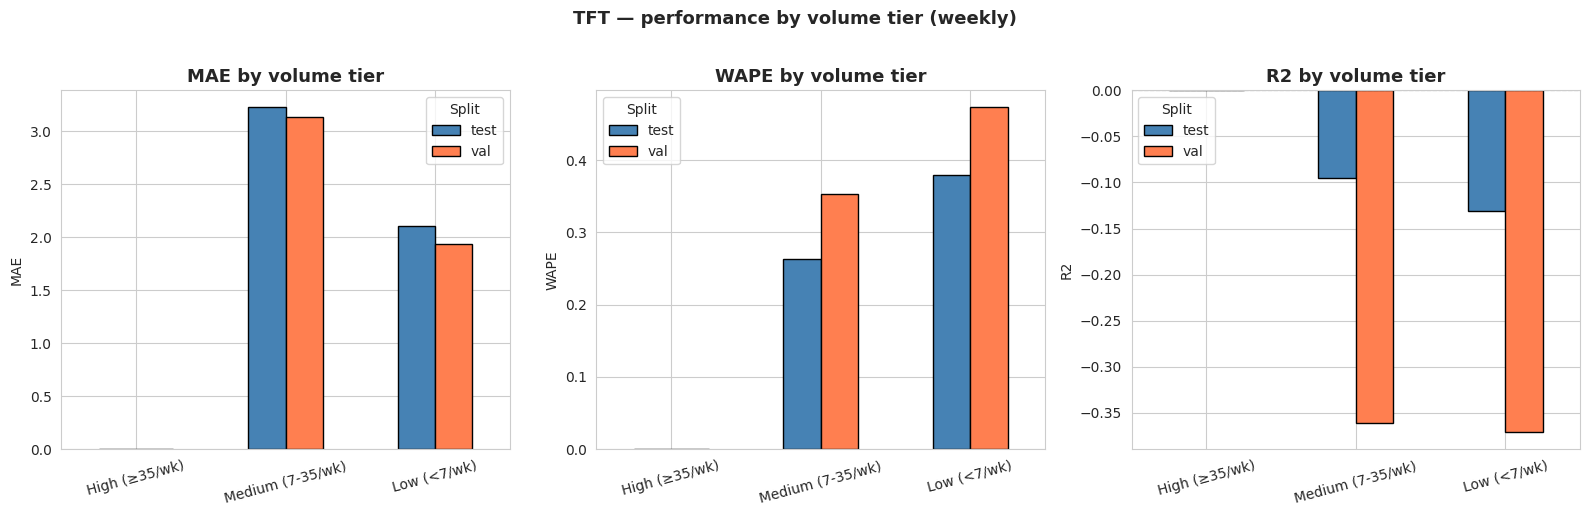

Saved: tft_weekly_by_volume_tier.png


In [14]:
try:
    df_orig_vol = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                              parse_dates=['week_start'])
except FileNotFoundError:
    df_orig_vol = df.copy()

item_volume = (df_orig_vol[df_orig_vol['split'] == 'train']
               .groupby('item_name')['quantity'].mean())

def assign_tier(avg):
    if avg >= 35:  return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else:          return 'Low (<7/wk)'

item_tiers    = item_volume.apply(assign_tier).rename('volume_tier').reset_index()
tier_order    = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']

metrics_with_tier = metrics_df.merge(item_tiers, on='item_name')
tier_results = (metrics_with_tier
                .groupby(['volume_tier', 'split'])
                .agg(n_items=('item_name', 'nunique'),
                     mae=('mae', 'mean'), wape=('wape', 'mean'),
                     smape=('smape', 'mean'), r2=('r2', 'mean'))
                .reset_index())

print("=" * 70)
print("TFT — Performance by volume tier")
print("=" * 70)
print(tier_results.to_string(index=False, float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['mae', 'wape', 'r2']):
    pivot = (tier_results
             .pivot(index='volume_tier', columns='split', values=metric)
             .reindex(tier_order))
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric.upper()} by volume tier')
    ax.set_ylabel(metric.upper())
    ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=15)
    if metric == 'r2':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.suptitle('TFT — performance by volume tier (weekly)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tft_weekly_by_volume_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tft_weekly_by_volume_tier.png")


## 13. Sample predictions across volume tiers

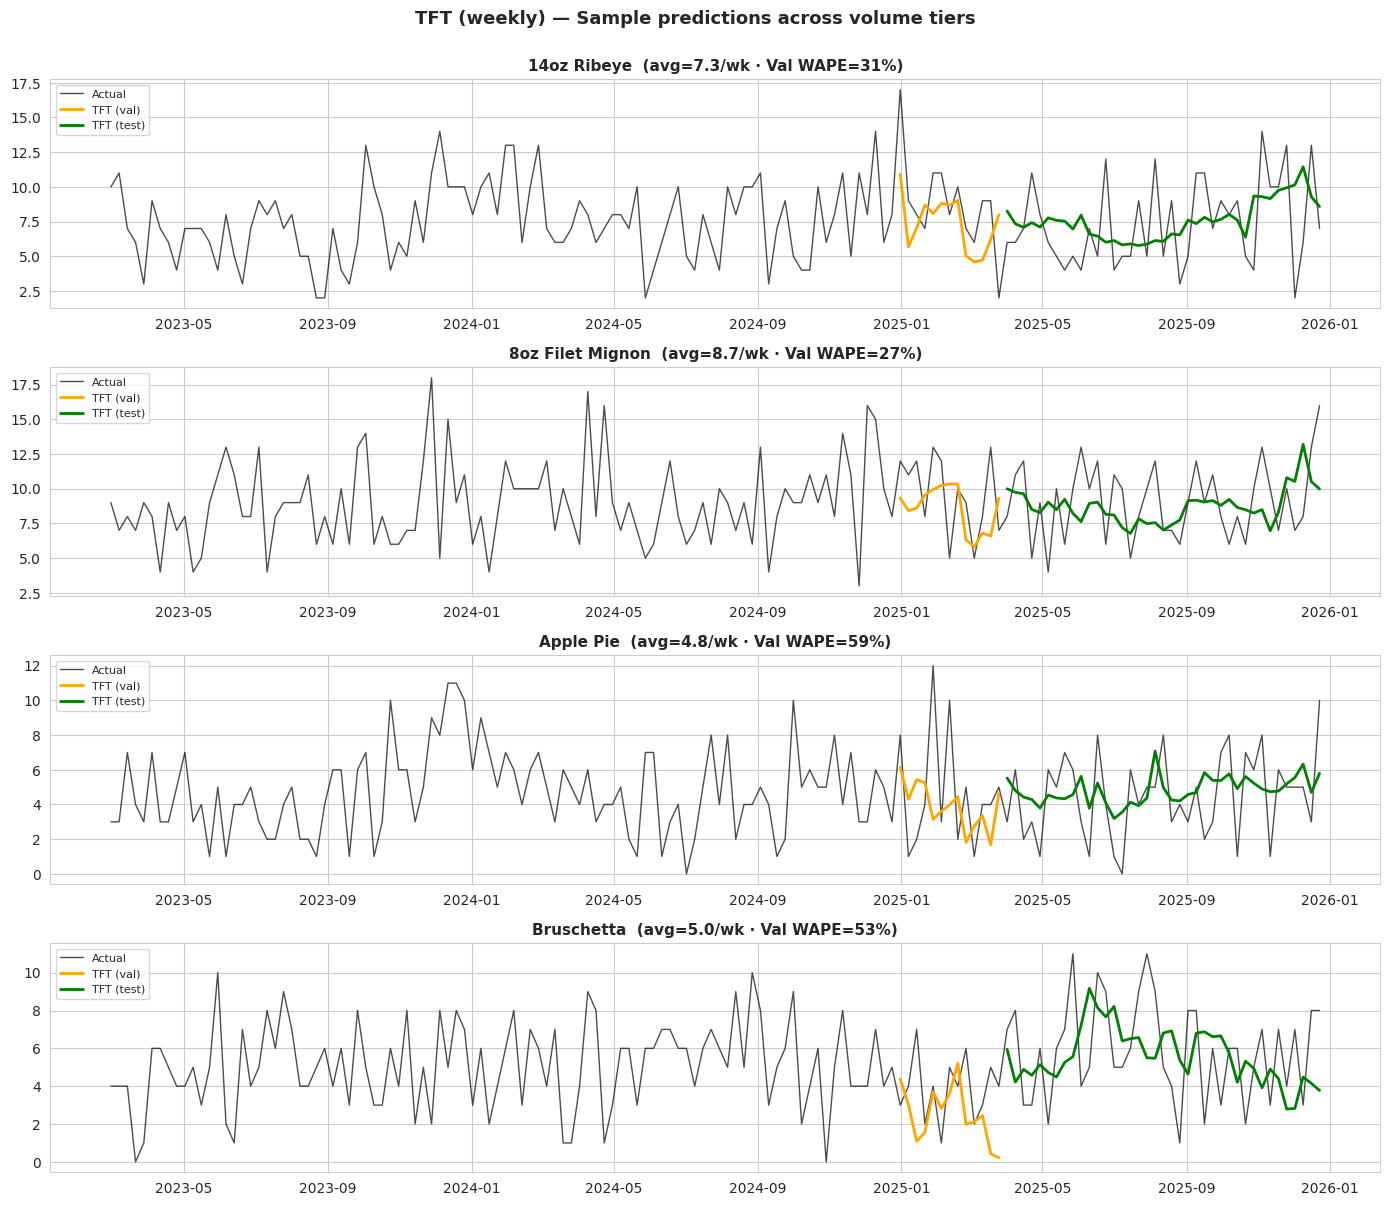

Saved: tft_weekly_sample_predictions.png


In [15]:
sample_items = []
for tier in tier_order:
    t_items = item_tiers[item_tiers['volume_tier'] == tier]['item_name'].tolist()
    sample_items.extend(t_items[:2] if len(t_items) >= 2 else t_items[:1])

fig, axes = plt.subplots(len(sample_items), 1, figsize=(14, 3 * len(sample_items)))
if len(sample_items) == 1:
    axes = [axes]

for ax, item in zip(axes, sample_items):
    item_full = df[df['item_name'] == item].sort_values('week_start')
    item_pred = predictions_df[predictions_df['item_name'] == item].sort_values('ds')
    avg       = item_volume.get(item, 0)

    ax.plot(item_full['week_start'], item_full['quantity'],
            color='black', linewidth=1, label='Actual', alpha=0.7)
    for split, color in [('val', 'orange'), ('test', 'green')]:
        sp = item_pred[item_pred['split'] == split]
        if len(sp):
            ax.plot(sp['ds'], sp['predicted'], color=color, linewidth=2,
                    label=f'TFT ({split})')

    val_w    = metrics_df[(metrics_df['item_name'] == item) & (metrics_df['split'] == 'val')]['wape'].values
    val_wstr = f"{val_w[0]:.0%}" if len(val_w) else 'n/a'
    ax.set_title(f"{item}  (avg={avg:.1f}/wk · Val WAPE={val_wstr})", fontsize=11)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('TFT (weekly) — Sample predictions across volume tiers',
             fontsize=13, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('tft_weekly_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tft_weekly_sample_predictions.png")


## 14. Residual diagnostics

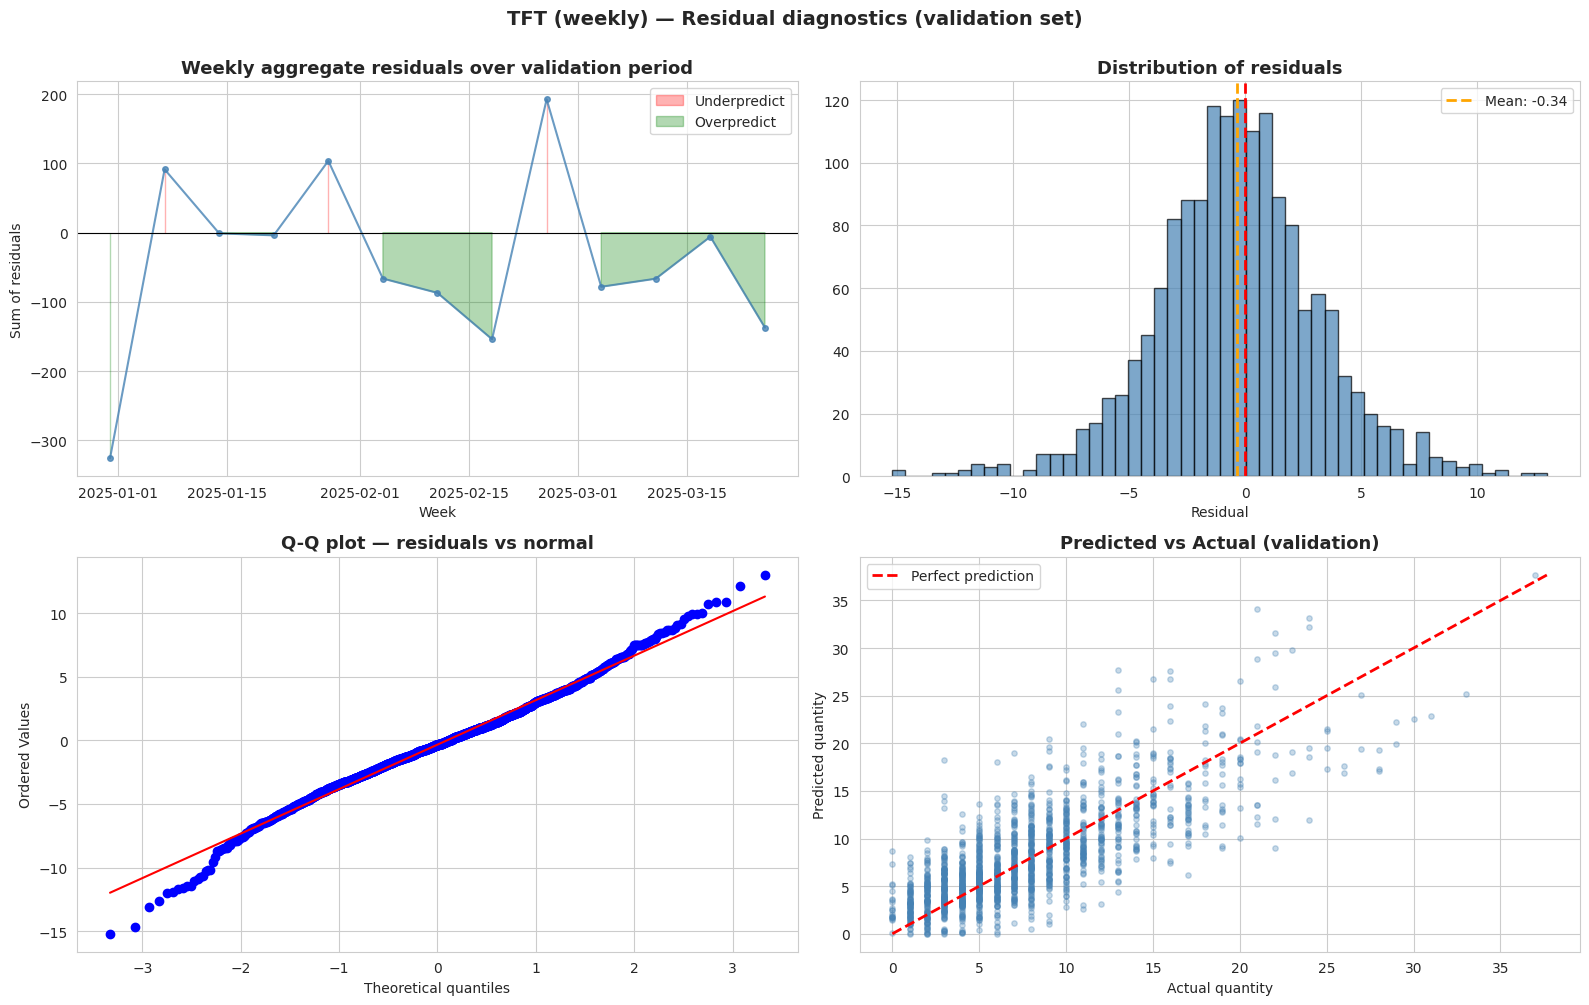

Residual statistics (validation):
  Mean:     -0.3390
  Median:   -0.3524
  Std:      3.5093
  Skewness: -0.0667
  Kurtosis: 1.1005


In [16]:
from scipy import stats as scipy_stats

val_pred_res = predictions_df[predictions_df['split'] == 'val'].copy()
val_pred_res['residual'] = val_pred_res['actual'] - val_pred_res['predicted']
val_pred_res['ds']       = pd.to_datetime(val_pred_res['ds'])

weekly_residuals = (val_pred_res
                    .groupby('ds')
                    .agg(sum_residual=('residual', 'sum'))
                    .reset_index())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(weekly_residuals['ds'], weekly_residuals['sum_residual'],
        color='steelblue', linewidth=1.5, alpha=0.8, marker='o', markersize=4)
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(weekly_residuals['ds'], 0, weekly_residuals['sum_residual'],
                where=(weekly_residuals['sum_residual'] > 0),
                alpha=0.3, color='red', label='Underpredict')
ax.fill_between(weekly_residuals['ds'], 0, weekly_residuals['sum_residual'],
                where=(weekly_residuals['sum_residual'] <= 0),
                alpha=0.3, color='green', label='Overpredict')
ax.set_title('Weekly aggregate residuals over validation period')
ax.set_xlabel('Week')
ax.set_ylabel('Sum of residuals')
ax.legend()

# 2. Histogram
ax = axes[0, 1]
sample_res = val_pred_res['residual'].sample(min(5000, len(val_pred_res)), random_state=42)
ax.hist(sample_res, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(sample_res.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean: {sample_res.mean():.2f}')
ax.set_title('Distribution of residuals')
ax.set_xlabel('Residual')
ax.legend()

# 3. Q-Q plot
ax = axes[1, 0]
scipy_stats.probplot(sample_res, dist='norm', plot=ax)
ax.set_title('Q-Q plot — residuals vs normal')

# 4. Predicted vs Actual
ax = axes[1, 1]
sample_ap = val_pred_res.sample(min(3000, len(val_pred_res)), random_state=42)
ax.scatter(sample_ap['actual'], sample_ap['predicted'],
           alpha=0.3, s=15, color='steelblue')
max_val = max(sample_ap['actual'].max(), sample_ap['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual quantity')
ax.set_ylabel('Predicted quantity')
ax.set_title('Predicted vs Actual (validation)')
ax.legend()

plt.suptitle('TFT (weekly) — Residual diagnostics (validation set)',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('tft_weekly_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print("Residual statistics (validation):")
print(f"  Mean:     {val_pred_res['residual'].mean():.4f}")
print(f"  Median:   {val_pred_res['residual'].median():.4f}")
print(f"  Std:      {val_pred_res['residual'].std():.4f}")
print(f"  Skewness: {scipy_stats.skew(val_pred_res['residual']):.4f}")
print(f"  Kurtosis: {scipy_stats.kurtosis(val_pred_res['residual']):.4f}")


## 15. Per-item WAPE distribution and outliers

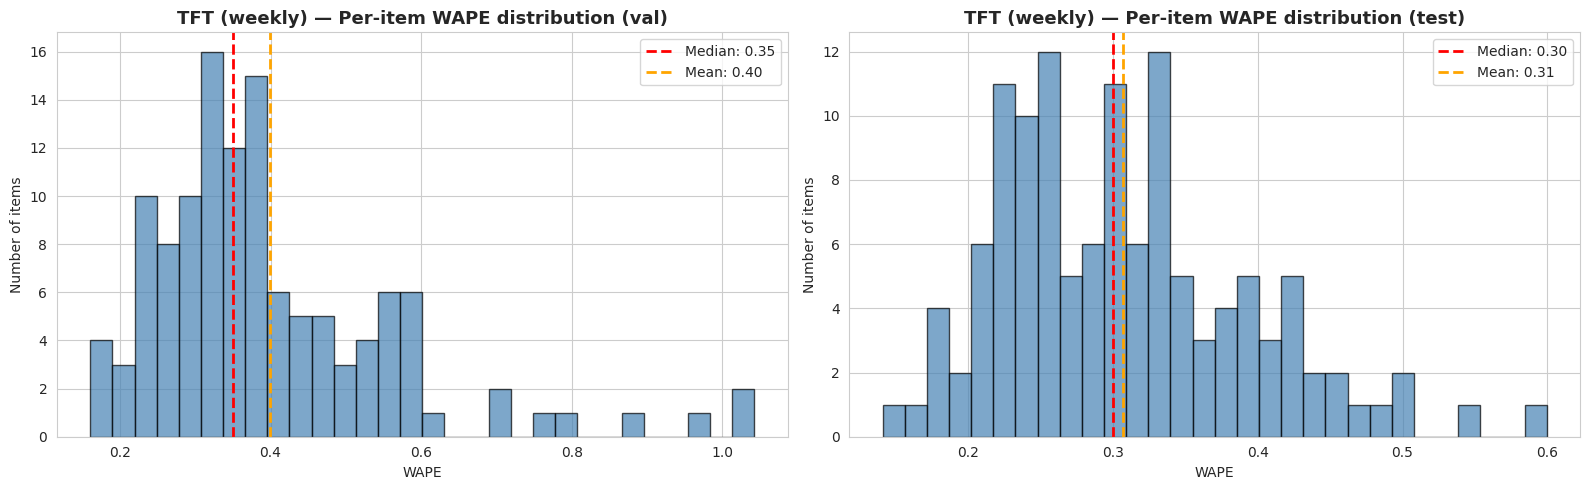

BEST 10 items (lowest WAPE on val):
             item_name    mae   wape      r2
    Fettuccine Alfredo 2.0996 0.1606  0.3881
      Beef Tacos (3pc) 2.2694 0.1612  0.4714
          Garlic Bread 1.5749 0.1692  0.7182
    Chicken Enchiladas 2.2949 0.1830  0.5335
             Black Tea 2.2064 0.2034  0.6619
    Philly Cheesesteak 3.0504 0.2076 -0.4696
            Iced Latte 1.6034 0.2149  0.2868
  Hot Dog with Mustard 5.4801 0.2298  0.1214
          Beef Lasagna 3.1079 0.2309  0.3890
Garlic Mashed Potatoes 1.6945 0.2319  0.5478

WORST 10 items (highest WAPE on val):
                      item_name    mae   wape      r2
                  Caprese Salad 2.4857 1.0424 -2.4168
                   Lemon Gelato 1.7255 1.0196 -0.8194
                       Prosecco 3.6208 0.9806 -3.0805
                  Sapporo Draft 2.4032 0.8678 -0.6106
              Vanilla Milkshake 2.0385 0.7794  0.0409
              Grilled Asparagus 2.5147 0.7602 -1.5346
      Green Tea Mochi Ice Cream 0.8745 0.7105 -1.161

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, split in zip(axes, ['val', 'test']):
    split_metrics = metrics_df[metrics_df['split'] == split]
    wape_clipped  = split_metrics['wape'].clip(upper=3)
    ax.hist(wape_clipped, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(wape_clipped.median(), color='red',    linestyle='--', linewidth=2,
               label=f'Median: {wape_clipped.median():.2f}')
    ax.axvline(wape_clipped.mean(),   color='orange', linestyle='--', linewidth=2,
               label=f'Mean: {wape_clipped.mean():.2f}')
    ax.set_title(f'TFT (weekly) — Per-item WAPE distribution ({split})')
    ax.set_xlabel('WAPE')
    ax.set_ylabel('Number of items')
    ax.legend()

plt.tight_layout()
plt.savefig('tft_weekly_wape_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 70)
print("BEST 10 items (lowest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split'] == 'val']
      .nsmallest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']]
      .to_string(index=False, float_format='%.4f'))

print("\n" + "=" * 70)
print("WORST 10 items (highest WAPE on val):")
print("=" * 70)
print(metrics_df[metrics_df['split'] == 'val']
      .nlargest(10, 'wape')[['item_name', 'mae', 'wape', 'r2']]
      .to_string(index=False, float_format='%.4f'))


## 16. Variable importance — what TFT learned to focus on

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


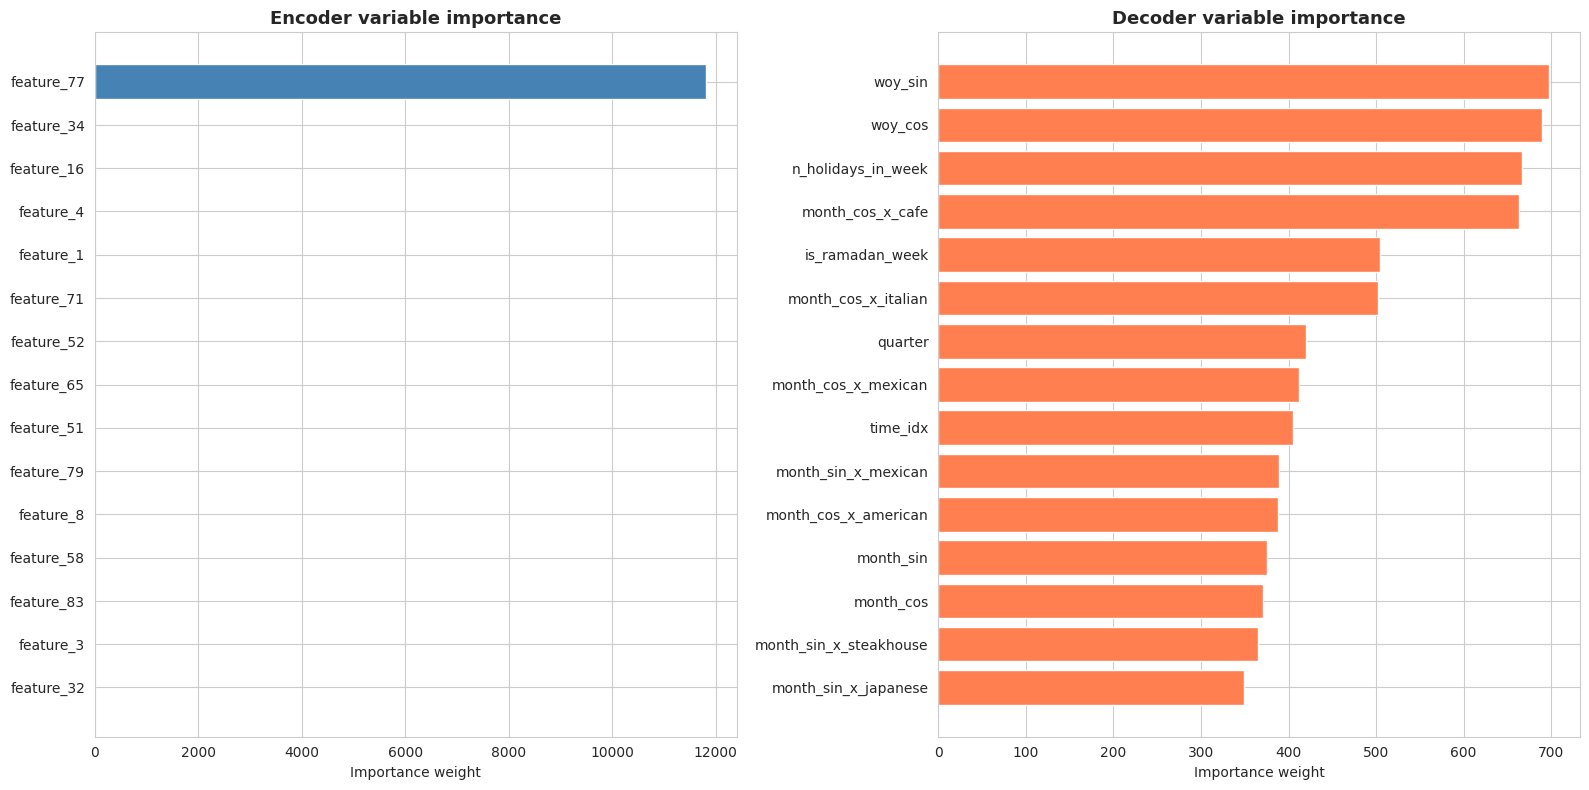

Saved: tft_variable_importance.png


In [18]:
try:
    raw_predictions = tft.predict(val_loader, mode='raw', return_x=True)
    interpretation  = tft.interpret_output(raw_predictions.output, reduction='sum')

    enc_importance = interpretation['encoder_variables'].cpu().numpy()
    enc_names      = (training_dataset.reals
                      + [v for v in training_dataset.flat_categoricals
                         if v in training_dataset.reals])
    # Fallback: use indices if names list is mismatched
    if len(enc_names) != len(enc_importance):
        enc_names = [f'feature_{i}' for i in range(len(enc_importance))]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    n_show  = min(15, len(enc_importance))
    top_enc = np.argsort(enc_importance)[-n_show:]
    axes[0].barh([enc_names[i] for i in top_enc], enc_importance[top_enc],
                 color='steelblue')
    axes[0].set_title('Encoder variable importance')
    axes[0].set_xlabel('Importance weight')

    dec_importance = interpretation['decoder_variables'].cpu().numpy()
    dec_names      = tv_known_reals[:len(dec_importance)]
    n_show  = min(15, len(dec_importance))
    top_dec = np.argsort(dec_importance)[-n_show:]
    axes[1].barh([dec_names[i] for i in top_dec], dec_importance[top_dec],
                 color='coral')
    axes[1].set_title('Decoder variable importance')
    axes[1].set_xlabel('Importance weight')

    plt.tight_layout()
    plt.savefig('tft_variable_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: tft_variable_importance.png")
except Exception as e:
    print(f"Variable importance extraction skipped: {e}")
    print("(This can happen depending on pytorch-forecasting version — safe to ignore.)")


## 17. Save model + predictions for FastAPI and notebook 06c

In [19]:
# Save model checkpoint
checkpoint_path = os.path.join(MODELS_DIR, 'tft.ckpt')
trainer.save_checkpoint(checkpoint_path)
print(f"Model checkpoint saved to {checkpoint_path}")

# Save predictions
pred_out = predictions_df[['ds', 'item_name', 'section', 'category',
                            'actual', 'predicted', 'split']]
pred_out.to_csv(os.path.join(DATASETS_DIR, 'tft_predictions_weekly.csv'), index=False)

# Save per-item metrics
metrics_df.to_csv(os.path.join(DATASETS_DIR, 'tft_metrics_weekly.csv'), index=False)

# Save summary
summary = {
    'model': 'tft',
    'arch': {
        'hidden_size':     32,
        'attention_heads': 2,
        'encoder_len':     MAX_ENCODER_LEN,
        'dropout':         0.2,
    },
    'training_time_sec': round(training_time, 1),
    'epochs_run':        trainer.current_epoch,
    'overall_metrics': {
        split: {
            k: float(v)
            for k, v in compute_metrics(
                predictions_df[predictions_df['split'] == split]['actual'].values,
                predictions_df[predictions_df['split'] == split]['predicted'].values,
            ).items()
            if not (isinstance(v, float) and np.isnan(v))
        }
        for split in ['val', 'test']
    },
}

with open(os.path.join(DATASETS_DIR, 'tft_summary_weekly.json'), 'w') as fh:
    json.dump(summary, fh, indent=2, default=str)

print("=" * 60)
print("✓ Saved:")
print(f"  Checkpoint:   {checkpoint_path}")
print(f"  Predictions:  tft_predictions_weekly.csv")
print(f"  Metrics:      tft_metrics_weekly.csv")
print(f"  Summary:      tft_summary_weekly.json")
print("=" * 60)


`weights_only` was not set, defaulting to `False`.


Model checkpoint saved to ../../models/tft/tft.ckpt
✓ Saved:
  Checkpoint:   ../../models/tft/tft.ckpt
  Predictions:  tft_predictions_weekly.csv
  Metrics:      tft_metrics_weekly.csv
  Summary:      tft_summary_weekly.json
